IMPLEMENTASI NAIVE BAYES - PREDIKSI KONDISI BARANG INVETARIS
Referensi : Jurnal JURNAL SISTEM INFORMASI DAN TEKNIK KOMPUTER  
Vol. 10, No. 2, (2025) ISSN: 2502-5899 - Mhd. Iskandar Madani Siahaan

1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, 
precision_score, recall_score, f1_score)

2. Masukan Dataset


In [8]:
df = pd.read_csv('Data Inventaris SMK Muhammadiyah 12 - Tahun 2025.csv', header=1)
print("=== Data Awal ===")
print(df.head())
print(f"\nTotal Data: {len(df)} baris")
print(f"Jumlah Kolom: {len(df.columns)}")

=== Data Awal ===
   NO   NAMA BARANG  MERK KODE BARANG TAHUN PENGADAAN  \
0   1  LAPTOP + SSD  Dell       LP001            2025   
1   2  LAPTOP + SSD  Dell       LP002            2025   
2   3  LAPTOP + SSD  Dell       LP003            2025   
3   4  LAPTOP + SSD  Dell       LP004            2025   
4   5  LAPTOP + SSD  Dell       LP005            2025   

  FREKUENSI PEMAKAIAN\n(1-5) UMUR BARANG\n(Tahun) KONDISI FISIK\n(1-5)  \
0                          5                    1                    5   
1                          5                    1                    5   
2                          5                    1                    5   
3                          5                    1                    5   
4                          5                    1                    5   

  KELENGKAPAN\n(1-5) LABEL KONDISI KETERANGAN            KATEGORI  
0                  4         LAYAK          —  Perangkat Komputer  
1                  4         LAYAK          —  Perangkat K

3. Praproses Data

In [10]:
print("\n=== Periksa Data Kosong ===")
print(df.isnull().sum())

# hapus baris dengan label kosong / tidak diketahui
df = df[df['LABEL KONDISI'] != 'TIDAK DIKETAHUI']

df = df.dropna(subset=[
    'LABEL KONDISI',
    'KONDISI FISIK\n(1-5)',
    'KELENGKAPAN\n(1-5)',
    'FREKUENSI PEMAKAIAN\n(1-5)',
    'UMUR BARANG\n(Tahun)',
    'TAHUN PENGADAAN'
])

# ganti nilai kosong numerik dengan 0
num_cols = [
    'TAHUN PENGADAAN',
    'FREKUENSI PEMAKAIAN\n(1-5)',
    'UMUR BARANG\n(Tahun)',
    'KONDISI FISIK\n(1-5)',
    'KELENGKAPAN\n(1-5)'
]

df[num_cols] = df[num_cols].fillna(0)

print(f"\nData Setelah Pembersihan: {len(df)} baris")

print("\nDistribusi Label:")
print(df['LABEL KONDISI'].value_counts())


=== Periksa Data Kosong ===
NO                            0
NAMA BARANG                   0
MERK                          0
KODE BARANG                   0
TAHUN PENGADAAN               0
FREKUENSI PEMAKAIAN\n(1-5)    0
UMUR BARANG\n(Tahun)          0
KONDISI FISIK\n(1-5)          0
KELENGKAPAN\n(1-5)            0
LABEL KONDISI                 0
KETERANGAN                    0
KATEGORI                      0
dtype: int64

Data Setelah Pembersihan: 201 baris

Distribusi Label:
LABEL KONDISI
LAYAK           177
KURANG LAYAK     20
TIDAK LAYAK       4
Name: count, dtype: int64


4. Encoding dan Pemisahan Data


In [11]:
le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df['LABEL KONDISI'])
print(f"\nKelas : {list(le.classes_)}")
print(f"Encoded Values: {list(range(len(le.classes_)))}")


Kelas : ['KURANG LAYAK', 'LAYAK', 'TIDAK LAYAK']
Encoded Values: [0, 1, 2]


5. Pilih Fitur dan Target

In [14]:
fitur = ['TAHUN PENGADAAN', 'FREKUENSI PEMAKAIAN\n(1-5)',
         'UMUR BARANG\n(Tahun)', 'KONDISI FISIK\n(1-5)', 'KELENGKAPAN\n(1-5)']

x = df[fitur]
y = df['Label_Encoded']

In [22]:
# Konversi semua fitur ke tipe numerik
x = x.apply(pd.to_numeric, errors='coerce')
x = x.fillna(0)

print("\n=== Tipe Data Fitur ===")
print(x.dtypes)
print("\n=== Sample Data Fitur ===")
print(x.head())


=== Tipe Data Fitur ===
TAHUN PENGADAAN               int64
FREKUENSI PEMAKAIAN\n(1-5)    int64
UMUR BARANG\n(Tahun)          int64
KONDISI FISIK\n(1-5)          int64
KELENGKAPAN\n(1-5)            int64
dtype: object

=== Sample Data Fitur ===
   TAHUN PENGADAAN  FREKUENSI PEMAKAIAN\n(1-5)  UMUR BARANG\n(Tahun)  \
0             2025                           5                     1   
1             2025                           5                     1   
2             2025                           5                     1   
3             2025                           5                     1   
4             2025                           5                     1   

   KONDISI FISIK\n(1-5)  KELENGKAPAN\n(1-5)  
0                     5                   4  
1                     5                   4  
2                     5                   4  
3                     5                   4  
4                     5                   4  


6. SPLIT DATA 80% TRAINING, 20% TESTING

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, 
        test_size=0.2, random_state=42, stratify=y)
print(f"\n=== PEMISAHAN DATA ===")
print(f"Jumlah Data Training: {len(X_train)} data (80%)")
print(f"Jumlah Data Testing: {len(X_test)} data (20%)")


=== PEMISAHAN DATA ===
Jumlah Data Training: 160 data (80%)
Jumlah Data Testing: 41 data (20%)


7. TRAINING MODEL NAIVE BAYES - Gunakan GaussianNB untuk fitur numerik kontinu Gunakan BernoulliNB untuk fitur biner (0/1)

In [23]:
# -- Gaussian NB (cocok untuk data numerik skala 1-5)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

# -- Bernoulli NB (seperti yang digunakan di jurnal)
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

8. Evaluasi Model

In [24]:
def evaluasi_model(nama, y_test, y_pred, le):
    print(f"\n{'='*50}")
    print(f"  EVALUASI: {nama}")
    print(f"{'='*50}")
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=le.classes_))
    return acc

acc_gnb = evaluasi_model("Gaussian Naive Bayes", y_test, y_pred_gnb, le)
acc_bnb = evaluasi_model("Bernoulli Naive Bayes", y_test, y_pred_bnb, le)


  EVALUASI: Gaussian Naive Bayes
Accuracy  : 97.56%

Classification Report:
              precision    recall  f1-score   support

KURANG LAYAK       0.80      1.00      0.89         4
       LAYAK       1.00      1.00      1.00        36
 TIDAK LAYAK       0.00      0.00      0.00         1

    accuracy                           0.98        41
   macro avg       0.60      0.67      0.63        41
weighted avg       0.96      0.98      0.96        41


  EVALUASI: Bernoulli Naive Bayes
Accuracy  : 87.80%

Classification Report:
              precision    recall  f1-score   support

KURANG LAYAK       0.00      0.00      0.00         4
       LAYAK       0.88      1.00      0.94        36
 TIDAK LAYAK       0.00      0.00      0.00         1

    accuracy                           0.88        41
   macro avg       0.29      0.33      0.31        41
weighted avg       0.77      0.88      0.82        41



d:\naive_bayes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\naive_bayes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\naive_bayes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\naive_bayes\.venv\Lib\site-packages\s

9. Confusion Matrix

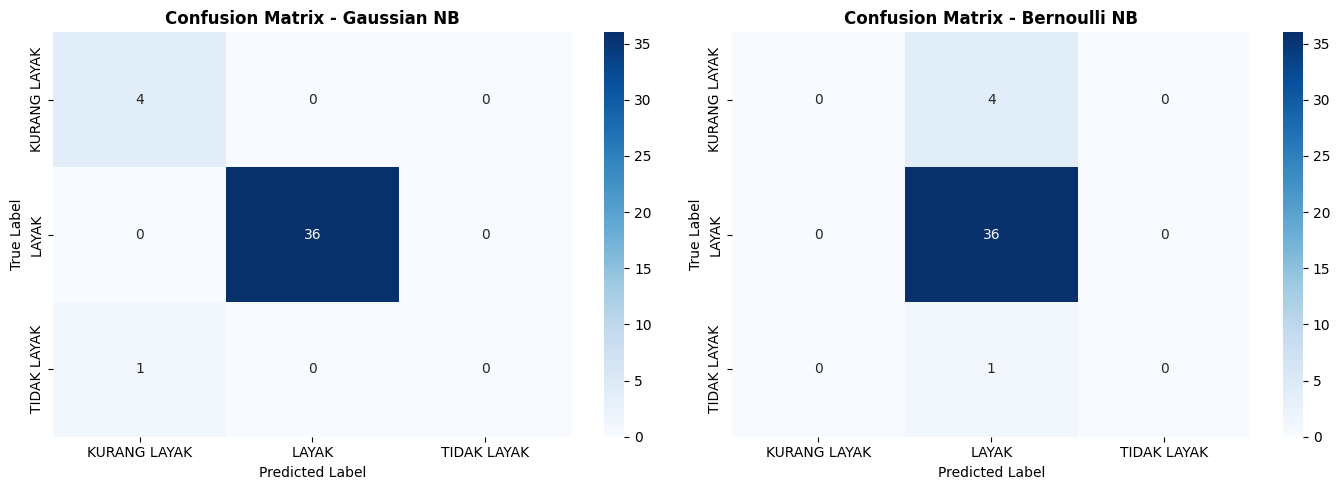


[INFO] Confusion matrix disimpan: confusion_matrix.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, nama in zip(axes,
                              [y_pred_gnb, y_pred_bnb],
                              ["Gaussian NB", "Bernoulli NB"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax.set_title(f'Confusion Matrix - {nama}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[INFO] Confusion matrix disimpan: confusion_matrix.png")

10. VISUALISASI DISTRIBUSI LABEL

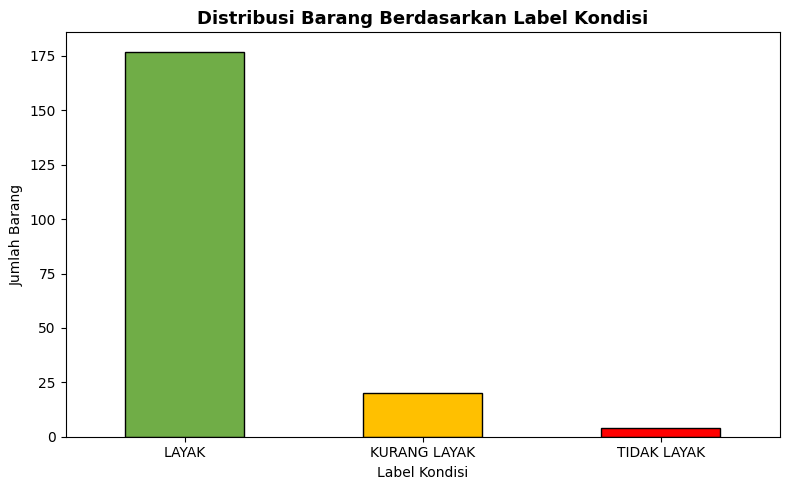

[INFO] Distribusi label disimpan: distribusi_label.png


In [28]:
plt.figure(figsize=(8, 5))
colors = ['#70AD47', '#FFC000', '#FF0000']
df['LABEL KONDISI'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribusi Barang Berdasarkan Label Kondisi', fontsize=13, fontweight='bold')
plt.xlabel('Label Kondisi')
plt.ylabel('Jumlah Barang')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] Distribusi label disimpan: distribusi_label.png")

11. Prediksi Data Baru

In [31]:
print("\n=== PREDIKSI DATA BARU ===")
data_baru = pd.DataFrame({
    'TAHUN PENGADAAN':      [2025, 2021, 2023, 2020, 2025],
    'FREKUENSI PEMAKAIAN\n(1-5)':  [5,    1,    3,    1,    4],
    'UMUR BARANG\n(Tahun)':        [0,    4,    2,    5,    0],
    'KONDISI FISIK\n(1-5)':        [5,    1,    3,    1,    4],
    'KELENGKAPAN\n(1-5)':          [5,    1,    2,    1,    5],
})

nama_barang_baru = [
    'Laptop Dell (Baru)',
    'Mikrotik (Lama)',
    'Switch TP-Link',
    'Tang Krimping (Lama)',
    'Router AP Tenda (Baru)'
]

pred_encoded = gnb.predict(data_baru)
pred_label   = le.inverse_transform(pred_encoded)

hasil = data_baru.copy()
hasil.insert(0, 'NAMA_BARANG', nama_barang_baru)
hasil['PREDIKSI'] = pred_label
print(hasil[['NAMA_BARANG', 'KONDISI FISIK\n(1-5)', 'UMUR BARANG\n(Tahun)', 'PREDIKSI']].to_string(index=False))

print("\n✅ Selesai! Model Naive Bayes berhasil dilatih dan dievaluasi.")


=== PREDIKSI DATA BARU ===
           NAMA_BARANG  KONDISI FISIK\n(1-5)  UMUR BARANG\n(Tahun)     PREDIKSI
    Laptop Dell (Baru)                     5                     0 KURANG LAYAK
       Mikrotik (Lama)                     1                     4  TIDAK LAYAK
        Switch TP-Link                     3                     2 KURANG LAYAK
  Tang Krimping (Lama)                     1                     5  TIDAK LAYAK
Router AP Tenda (Baru)                     4                     0 KURANG LAYAK

✅ Selesai! Model Naive Bayes berhasil dilatih dan dievaluasi.
